In [6]:
# Cell 1 — Load dataset
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
print(f"Train: {train_images.shape} | Test: {test_images.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28) | Test: (10000, 28, 28)


## Data Preprocessing

Raw pixels are flattened from 28×28 matrices to 784-dimensional vectors and normalised to [0, 1] to stabilise gradient descent.

In [7]:
X_train = train_images.reshape(-1, 784).astype("float32") / 255.0
X_test  = test_images.reshape(-1, 784).astype("float32") / 255.0
print(f"X_train: {X_train.shape} | range: [{X_train.min():.1f}, {X_train.max():.1f}]")

X_train: (60000, 784) | range: [0.0, 1.0]


## Model Architecture

A Multilayer Perceptron (MLP) with ReLU activations and Dropout regularisation.

In [8]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(784,)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64,  activation="relu"),
    keras.layers.Dense(10,  activation="softmax"),
], name="MNIST_MLP")

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "MNIST_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [9]:
history = model.fit(
    X_train, train_labels,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1,
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8489 - loss: 0.5135 - val_accuracy: 0.9553 - val_loss: 0.1688
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9396 - loss: 0.2061 - val_accuracy: 0.9672 - val_loss: 0.1190
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9550 - loss: 0.1529 - val_accuracy: 0.9725 - val_loss: 0.0976
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9619 - loss: 0.1250 - val_accuracy: 0.9753 - val_loss: 0.0865
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9671 - loss: 0.1065 - val_accuracy: 0.9792 - val_loss: 0.0783
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9731 - loss: 0.0899 - val_accuracy: 0.9783 - val_loss: 0.0778
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9748 - loss: 0.0799 - val_accuracy: 0.9803 - val_loss: 0.0707
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9770 - loss: 0.0728 - val_accuracy:

## Evaluation

In [10]:
import numpy as np
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

test_loss, test_acc = model.evaluate(X_test, test_labels, verbose=0)
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test Loss     : {test_loss:.4f}\n")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(classification_report(test_labels, y_pred, digits=4))

Test Accuracy : 0.9782  (97.82%)
Test Loss     : 0.0727

              precision    recall  f1-score   support

           0     0.9798    0.9908    0.9853       980
           1     0.9825    0.9921    0.9873      1135
           2     0.9776    0.9748    0.9762      1032
           3     0.9723    0.9733    0.9728      1010
           4     0.9708    0.9817    0.9762       982
           5     0.9841    0.9742    0.9792       892
           6     0.9894    0.9770    0.9832       958
           7     0.9784    0.9698    0.9741      1028
           8     0.9695    0.9784    0.9739       974
           9     0.9780    0.9683    0.9731      1009

    accuracy                         0.9782     10000
   macro avg     0.9783    0.9780    0.9781     10000
weighted avg     0.9782    0.9782    0.9782     10000



## Learning Curves

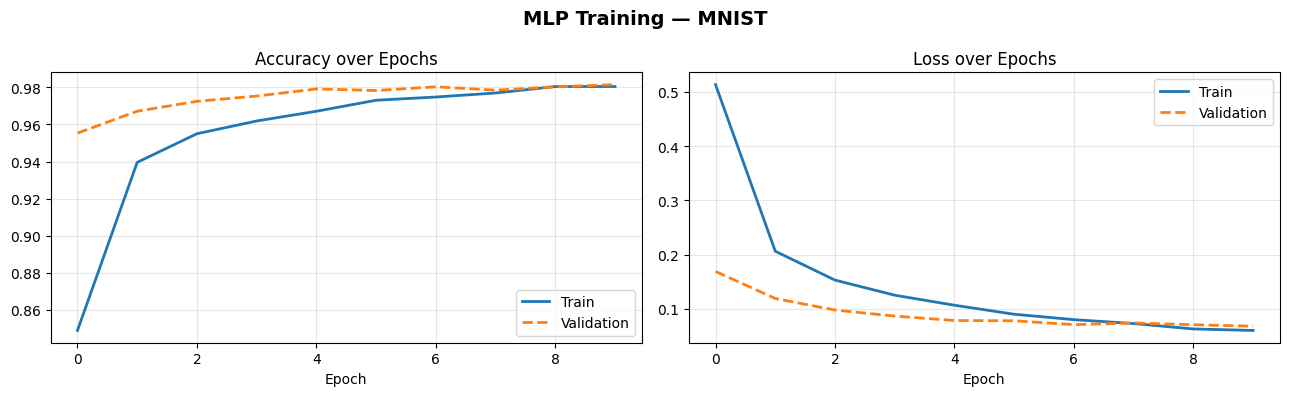

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (tr, val), title in zip(
    axes,
    [("accuracy","val_accuracy"), ("loss","val_loss")],
    ["Accuracy over Epochs", "Loss over Epochs"],
):
    ax.plot(history.history[tr],  label="Train",      linewidth=2)
    ax.plot(history.history[val], label="Validation", linewidth=2, linestyle="--")
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("MLP Training — MNIST", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## Confusion Matrix

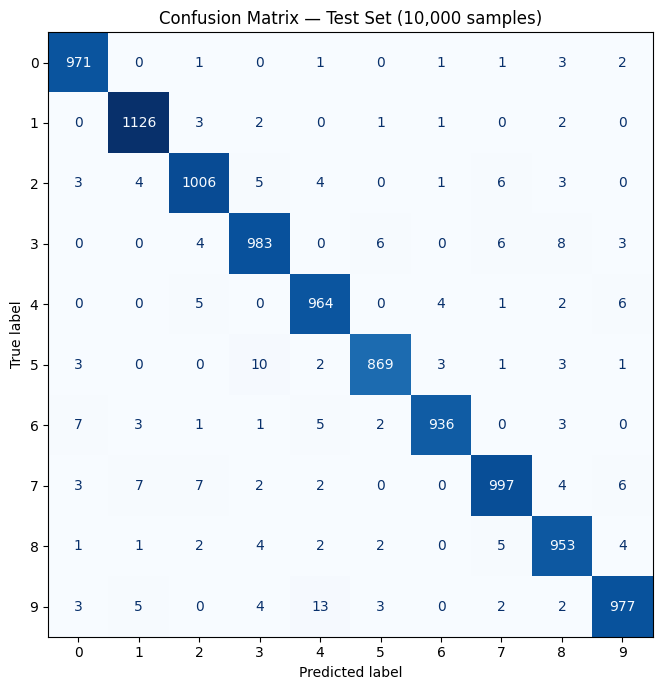

In [12]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    test_labels, y_pred,
    display_labels=range(10),
    cmap="Blues", colorbar=False, ax=ax,
)
ax.set_title("Confusion Matrix — Test Set (10,000 samples)")
plt.tight_layout(); plt.show()